## Working with FIRE Data

Here we show how the Toolbox can be used to open FIRE data which is provided as data trees. We also show ways how to plot the data which one may find useful.

We start, as usual, by opening the standard `esa-cci` data store.

In [1]:
from xcube.core.store import new_data_store

cci_store = new_data_store('esa-cci')

As next step, we can list the datasets which are provided as datatrees. Some of these are `FIRE` datasets.

In [2]:
list(cci_store.get_data_ids(data_type="datatree"))

['esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel',
 'esacci.FIRE.mon.L3S.BA.multi-sensor.multi-platform.SYN.v1-1.pixel',
 'esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.2-0.pixel',
 'esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.v1-1.pixel',
 'esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A03.v1-2.Siberia',
 'esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A02.v1-2.Amazonia',
 'esacci.LC.yr.L4.Map.multi-sensor.multi-platform.HRLC10-A01.v1-2.Africa',
 'esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A03.v1-2.Siberia',
 'esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A02.v1-2.Amazonia',
 'esacci.LC.5-yrs.L4.Map.multi-sensor.multi-platform.HRLC30-A01.v1-2.Africa',
 'esacci.LC.5-yrs.L4.CHANGE.multi-sensor.multi-platform.HRLCC30-A03.v1-2.Siberia',
 'esacci.LC.5-yrs.L4.CHANGE.multi-sensor.multi-platform.HRLCC30-A02.v1-2.Amazonia',
 'esacci.LC.5-yrs.L4.CHANGE.multi-sensor.multi-platform.HRLCC30-A01.v1-2.Africa',
 'esacci.VEGE

We pick one of these datasets which is based on Sentinel-2 MSI data over Africa.

In [3]:
fire_dataset = "esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.2-0.pixel"

As first step, we have a look at the potential opener parameters.

In [4]:
cci_store.get_open_data_params_schema(fire_dataset)

One entry that we don't see when opening datasets of other type is the property place_names. If we extend this, we see a listing of 116 tiles. Each of these identifiers stands for a different area. To see what these areas stand for, you can have a look at this document: https://climate.esa.int/media/documents/Fire_cci_D2.4.4_PUG-SFD_v2.0.pdf . It includes a graphic where you can see the placement of the tiles.

For convenience, we also show this image here:

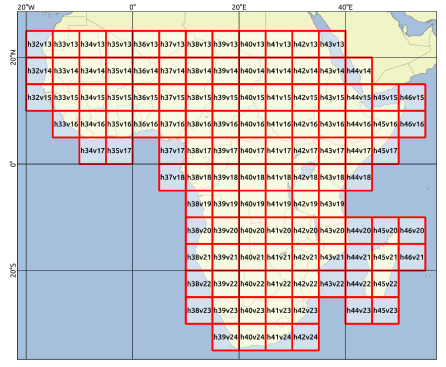

In [5]:
from IPython import display

display.Image("Location_Fire_Tiles.png")

We now pick one of the places located right north of the equator, located mostly within the Central African Republic.

In [6]:
places = ["h40v16"]

We now open the fire dataset with this one place.

In [7]:
fire_dt = cci_store.open_data(
    fire_dataset,
    place_names=places
)
fire_dt

<xarray.DataTree 'esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.2-0.pixel'>
Group: /
└── Group: /
        Dimensions:    (time: 12, y: 27000, x: 27000, bnds: 2)
        Coordinates:
          * time       (time) datetime64[ns] 96B 2019-01-16T12:00:00 ... 2019-12-16T1...
            time_bnds  (time, bnds) datetime64[ns] 192B dask.array<chunksize=(12, 2), meta=np.ndarray>
          * x          (x) float64 216kB 20.0 20.0 20.0 20.0 ... 25.0 25.0 25.0 25.0
          * y          (y) float64 216kB 10.0 10.0 10.0 9.999 ... 5.001 5.0 5.0 5.0
        Dimensions without coordinates: bnds
        Data variables:
            CL         (time, y, x) uint8 9GB dask.array<chunksize=(1, 1800, 1800), meta=np.ndarray>
            JD         (time, y, x) int16 17GB dask.array<chunksize=(1, 1800, 1800), meta=np.ndarray>
            LC         (time, y, x) uint8 9GB dask.array<chunksize=(1, 1800, 1800), meta=np.ndarray>
        Attributes:
            Conventions:             CF-1.7
          

By asking for that one key, we can now get the dataset from the datatree.

In [8]:
ds = fire_dt.get(places[0]).to_dataset()
ds

<xarray.Dataset> Size: 35GB
Dimensions:    (time: 12, y: 27000, x: 27000, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 96B 2019-01-16T12:00:00 ... 2019-12-16T1...
    time_bnds  (time, bnds) datetime64[ns] 192B dask.array<chunksize=(12, 2), meta=np.ndarray>
  * x          (x) float64 216kB 20.0 20.0 20.0 20.0 ... 25.0 25.0 25.0 25.0
  * y          (y) float64 216kB 10.0 10.0 10.0 9.999 ... 5.001 5.0 5.0 5.0
Dimensions without coordinates: bnds
Data variables:
    CL         (time, y, x) uint8 9GB dask.array<chunksize=(1, 1800, 1800), meta=np.ndarray>
    JD         (time, y, x) int16 17GB dask.array<chunksize=(1, 1800, 1800), meta=np.ndarray>
    LC         (time, y, x) uint8 9GB dask.array<chunksize=(1, 1800, 1800), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel...
    date_created:            2026-02-27T14:22:43.806571
    processing_level:        L3S
    time_coverage_start:     2019-01-01T00:00:00
    time_coverage_end:       2020-01-01T00:00:00
    time_coverage_duration:  P365DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

We see that the spatial coordinates are given as `x` and `y` rather than `lat` and `lon`. However, as the dataset's coordinate reference system is WGS84, we don't need to reproject here. We simply rename.

In [9]:
ds = ds.rename({"x": "lon", "y": "lat"})

Next, we see that the dataset is actually quite large. If we want to plot it, we may run into memory issues. Let's for starters plot a subset where we only show each tenth pixel along the spatial dimensions. We pick the first time value.

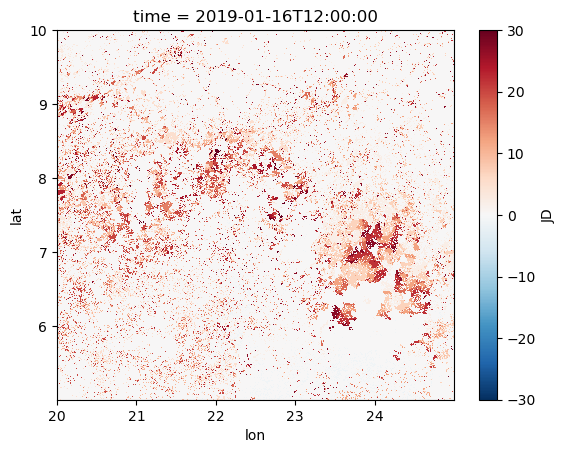

In [10]:
ds.JD.isel({"time": 0, "lon": slice(0, 27000, 10), "lat": slice(0, 27000, 10)}).plot()

The color bar does not seem to be a good choice, and we'll come to that in a moment. What else we can see now is that there seems to be an interesting pattern in the southeastern part. We therefore cut the dataset to that section using the `subset_spatial` operation. You can also find more information on any operation in the [Documentation of the Toolbox](https://esa-climate-toolbox.readthedocs.io/en/latest/api_reference.html#operations).

In [11]:
region = (24.5, 5.7, 25, 6.2) # min_lon, min_lat, max_lon, max_lat

In [12]:
from esa_climate_toolbox.core import get_op

subset_spatial = get_op("subset_spatial")

In [13]:
ds = subset_spatial(ds, region=region)
ds

<xarray.Dataset> Size: 350MB
Dimensions:    (time: 12, lat: 2701, lon: 2700, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 96B 2019-01-16T12:00:00 ... 2019-12-16T1...
    time_bnds  (time, bnds) datetime64[ns] 192B dask.array<chunksize=(12, 2), meta=np.ndarray>
  * lon        (lon) float64 22kB 24.5 24.5 24.5 24.5 ... 25.0 25.0 25.0 25.0
  * lat        (lat) float64 22kB 6.2 6.2 6.2 6.199 6.199 ... 5.7 5.7 5.7 5.7
Dimensions without coordinates: bnds
Data variables:
    CL         (time, lat, lon) uint8 88MB dask.array<chunksize=(1, 1080, 900), meta=np.ndarray>
    JD         (time, lat, lon) int16 175MB dask.array<chunksize=(1, 1080, 900), meta=np.ndarray>
    LC         (time, lat, lon) uint8 88MB dask.array<chunksize=(1, 1080, 900), meta=np.ndarray>
Attributes: (12/16)
    Conventions:                CF-1.7
    title:                      esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Senti...
    date_created:               2026-02-27T14:22:43.806571
    processing_level:           L3S
    time_coverage_start:        2019-01-01T00:00:00
    time_coverage_end:          2020-01-01T00:00:00
    ...                         ...
    geospatial_lon_max:         24.999999999313346
    geospatial_lat_resolution:  0.0001851851851855102
    geospatial_lat_min:         5.699814814814815
    geospatial_lat_max:         6.200000000000001
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((24.499999999382013 5.699814814814815...

Now that we have created a subset, we can take care of a proper visualisation of the JD variable. As a matter of fact, this variable has a special encoding. The value 0 indicates that a pixel has not been burned, -1 stands for pixels that were not observed in the month (e.g., due to high cloud coverage), and -2 stands for pixels that cannot be burned due to the type of land cover. For all other pixels, the values between 1-366 denote the day of year in which first a fire was detected. The dataset is divided into months, meaning that for January the value range is between 1 and 31, for February 32 to 59, and so on.
We aim to go for a visualisation where the julian day is scaled for each month to the same scale of red shades. But first, we define the colors, values and labels for the three catagories between -2 and 0.

In [14]:
base_category_colors = [
    "#1e90ff",  # dodger blue
    "#91a3b0",  # cadet grey
    "#000000",  # black
]
base_category_labels = [
    "Non-burnable",
    "Not observed",
    "Unburnt"
]
base_category_values = [-2, -1, 0]

Now that we have this defined, we can continue with the definition of the red color range. For this, we take the predefined "Reds" color map from the matplotlib package and divide it into 31 categories. We already add the first three colors at the beginning.

In [15]:
import matplotlib as plt
import numpy as np

cont_cmap = plt.colormaps["Reds"]
cont_colors = cont_cmap(np.linspace(0.2, 1, num=31))
colors = base_category_colors + cont_colors.tolist()

Just to see what color map we will end up with, we display it as a ListedColorMap.

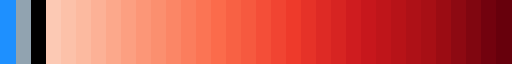

In [16]:
from matplotlib.colors import ListedColormap

ListedColormap(colors, name="FIRE LC Color Map")

Looks good! We may now continue with creating labels for the days. For the sake of readability, we do not define a label for each day, but for every fifth day. Using these labels will cause that in the legend we will see the day of the month, not the day of the year.

In [17]:
labels = [""] * 31
for i in range(5, 31, 5):
    labels[i] = i
labels = base_category_labels + labels

Now, we have to define the actual indices for each month separately, as the value ranges change with every month. For this, we determine the range from the number of days per month (as we only deal with the year 2019, we don't have to bother with the issue of leap years).

In [18]:
days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

Finally we can define an auxiliary method that can create a plot for each month. The method works as follows: 

1. define the JD value range for the month from summming up the days per month.
2. Create month-specific arrays `month_colors` and `month_labels` by removing the last values. This step is necessary so the arrays have the same length as `color_map_values`.
3. We create an indexers dictionary to indicate which time step of the dataset we are interested in.
4. We use that time information to create a more appealing title.
5. Lastly, we adjust the size of the figure.

All these parameters are passed to the `plot_catagorical` operation to create a plot that correctly considers 

In [19]:
plot_categorical = get_op("plot_categorical")

In [20]:
import pandas as pd
%matplotlib inline

def plot_jd(month: int):
    vmin = 1 + sum(days_per_month[:month - 1])
    vmax = sum(days_per_month[:month])
    month_values = base_category_values + list(range(vmin, vmax))

    month_colors = colors[:days_per_month[month - 1] + 3]
    month_labels = labels[:days_per_month[month - 1] + 3]
    
    time = ds.time.values[month - 1]
    indexers = dict(
        time=time
    )

    month_as_name = pd.Timestamp(ds.time.values[month - 1]).strftime("%B")
    title = f"First day in {month_as_name} 2019 in which a fire was detected in the Mbomou prefecture, Central African Republic"

    figsize=(6, 5)
    
    plot_categorical(
        ds,
        "JD",
        indexers=indexers,
        title=title,
        color_scheme_values=month_values,
        color_scheme_colors=month_colors,
        color_scheme_labels=month_labels,
        properties=dict(figsize=figsize)
    )

Now that we have this method, we can use it for months from 1 - 12. Righ now, we plot data for January and December, as these months show most fires.

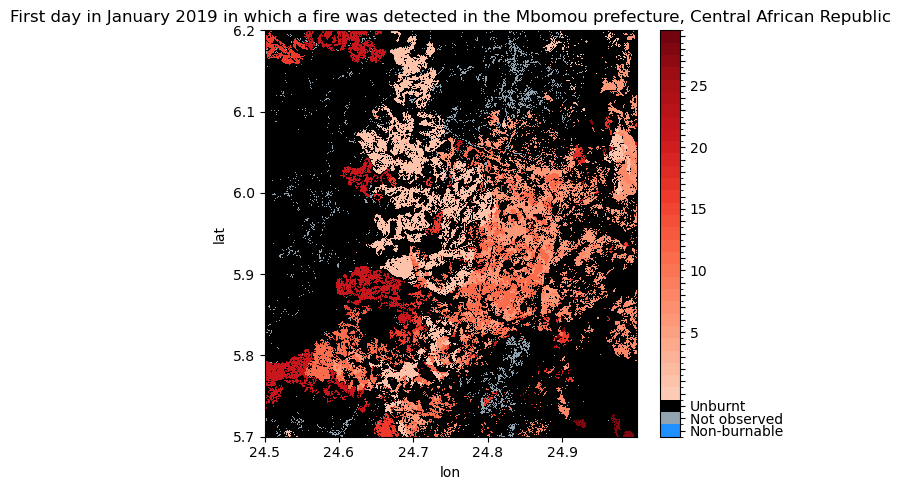

In [21]:
plot_jd(1)

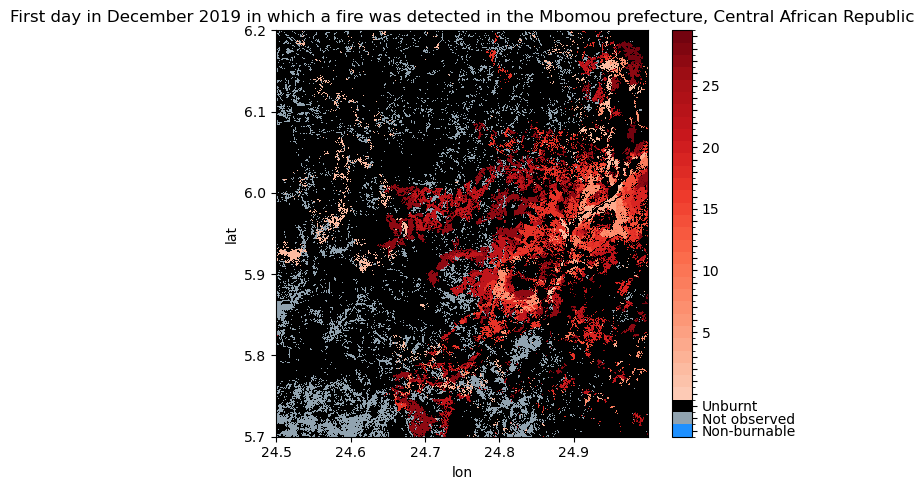

In [22]:
plot_jd(12)

Now that we plot th `JD` variable, we can also have a look at the `LC` variable. This is somewhat easier, as the data is using a regular value range. Also, this color map is predefined in the toolbox.

In [23]:
def plot_lc(month: int):
    time = ds.time.values[month - 1]
    indexers = dict(
        time=time
    )

    month_as_name = pd.Timestamp(ds.time.values[month - 1]).strftime("%B")
    title = f"Land cover in {month_as_name} 2019 of burnt areas in the Mbomou prefecture, Central African Republic"

    figsize=(11, 5)
    
    plot_categorical(
        ds, 
        "LC", 
        indexers=indexers, 
        title=title, 
        color_scheme_name="land_cover_fire_cci", 
        properties=dict(figsize=figsize)
    )

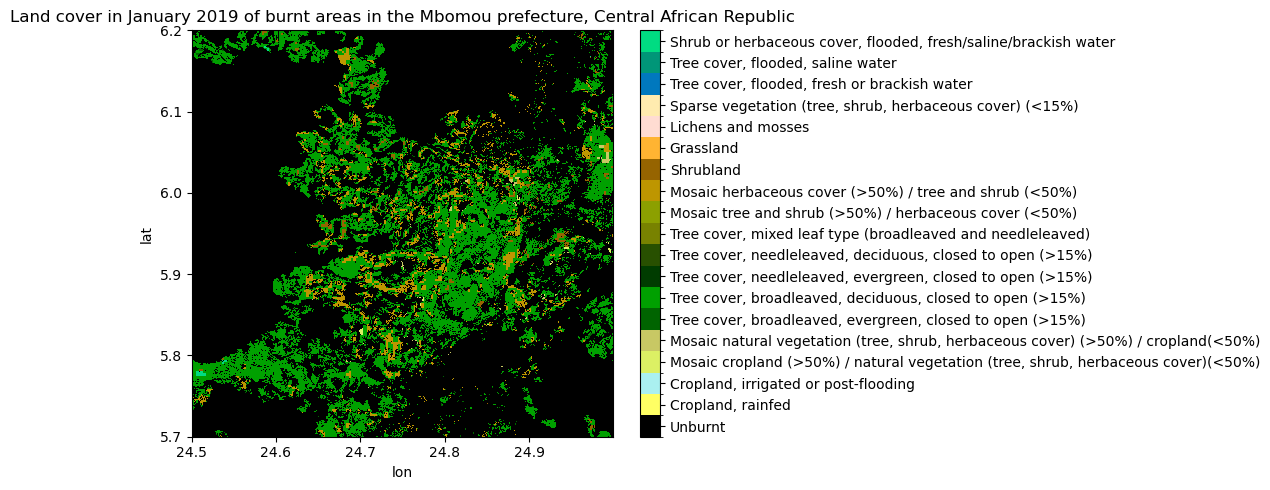

In [24]:
plot_lc(1)

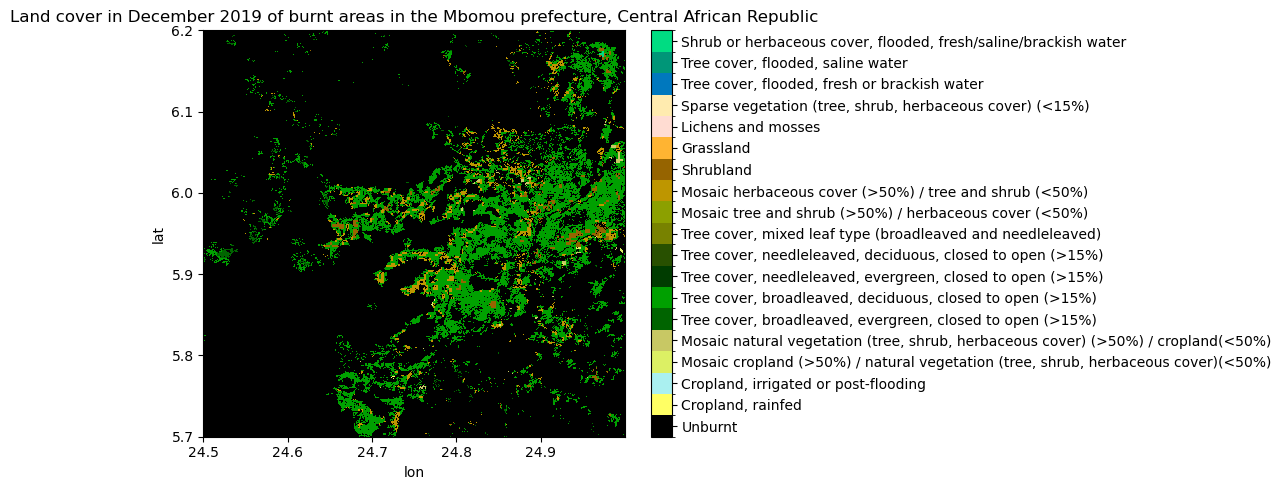

In [25]:
plot_lc(12)